In [7]:
from py_files.setup import *
setup_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Effect of $\varepsilon^S$ and $\phi$ on `wages` and `welfare`

**Goal:** Describe effect of the `capital supply elasticity` and of the friction of moving between sectors, i.e.
\begin{align*}
    &\frac{d\log w_C}{d\log (1-\tau_t)}(\varepsilon^S), \quad
    \frac{d\log w_I}{d\log (1-\tau_t)}(\varepsilon^S), \quad
    \frac{d\log r_K}{d\log (1-\tau_t)}(\varepsilon^S), \quad \\
    &\frac{d\log w_C}{d\log (1-\tau_t)}(\varepsilon^S(\phi)), \quad
    \frac{d\log w_I}{d\log (1-\tau_t)}(\varepsilon^S(\phi)), \quad
    \frac{d\log r_K}{d\log (1-\tau_t)}(\varepsilon^S(\phi)), \quad 
\end{align*}
To discuss the effect of the `capital supply elasticity` and relation to NCM, through *Chamley-Judd*.

**Output:**

1. Plot the wage/rent effects in $(w_I/r_K, \varepsilon^S)$.
2. Plot the wage/rent effects in $(w_I/r_K, \phi)$.
3. Do the simulation for some chosen elasticities.

*`1. prep`*

In [8]:
m = CapIncModel_single()
out = m.calibrate(target_elas=m.phi, verbose=False)

*pick shock path*

In [9]:
T=25; tau0=0.0; rho=0.85; tail=50; tau_ss=0.0; tauT=-0.1

# permanent shock
net_long, tau_long, dlog_net_long, tauT = shocks.perm_tc(
    T=T, tau0=tau0, tauT=tauT, rho=rho, tail=tail,
)
# temp shock (uncomment to use instead)
# tauT = 0.0
# net_long, tau_long, dlog_net_long, tauT = shocks.temp_tc(T=T, tail=tail)

sim_raw = m.solve_transition(tau_path=tau_long, tau_terminal=tauT)
ss, sim = build_output_single.welfare_effects(
    m, sim_raw, tau_long, dlog_net_long, T=T, tail=tail, tau_ss=tau_ss
)
welf = elas.welfare_incidence(sim)

*implied elasticities*

In [10]:
out_base = elas.dem_sup_elas(m, tau=0.0)
print(f"epsD={out_base['epsD']:.4f}  epsS_LR={out_base['epsS_LR']:.4f}  epsS_SR={out_base['epsS_SR']:.4f}")

# implied wage- and rent elasticities
# res = elas.wr_tax_elas(m, elas_out=out_base)
print_elas(out_base)

# NGM (alpha_L=beta_L=2/3) — uncomment to compare
# res_ncm = elas.wr_tax_elas(m, elas_out=out_base, epsS_LR=10000000000)
# print({k: round(v, 3) for k, v in res_ncm.items()})

epsD=1.4922  epsS_LR=1.4437  epsS_SR=0.1193
────────────────────────────────
  epsD           1.4922
  epsS_LR        1.4437
  epsS_SR        0.1193
────────────────────────────────


*perform sweep and plot*

In [11]:
sweep_res = run_sweeps(m, out_base, tau_long, dlog_net_long, tauT,
                       T, tail, tau_ss)

Running epsS sweep …
Running phi marginal sweep …
Running phi welfare sweep …
Done.


*plot*

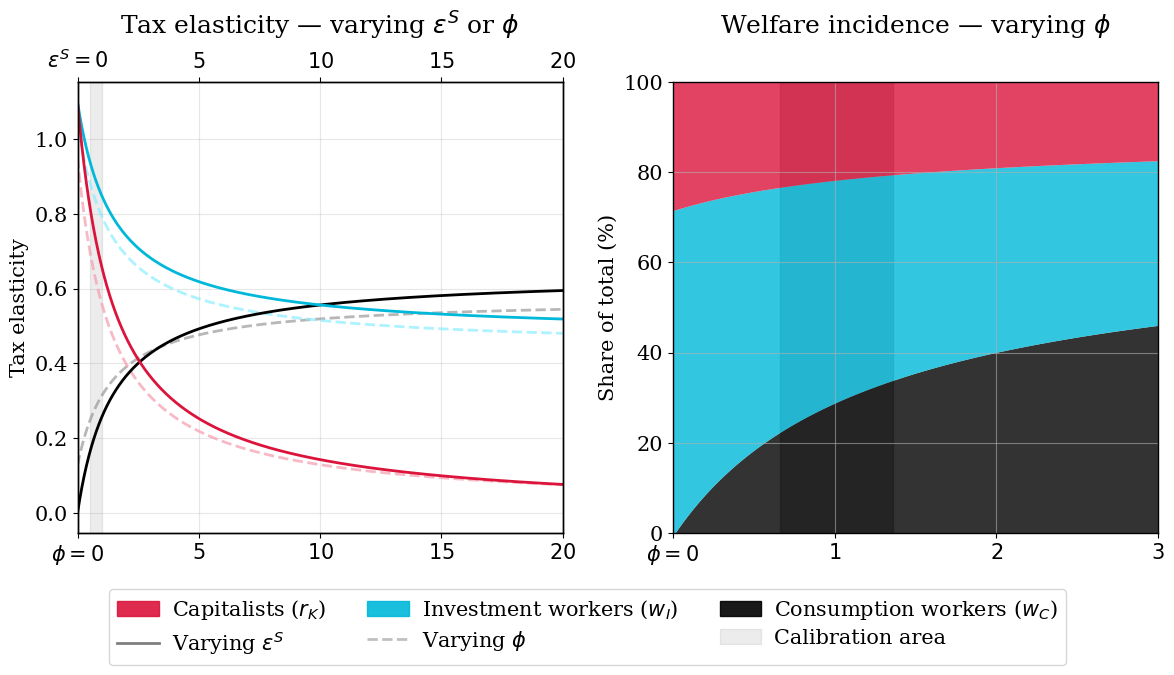

In [18]:
plot_sweep(sweep_res, savepath='0_output/main_arg.png')